### Dependencies

In [1]:
%pip install matplotlib
%pip install numpy
%pip install torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Randomness and reproducibility

In [2]:
import numpy as np, random, torch
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### EDA (Exploratory Data Analysis)

In [3]:
# General settings for plots

import matplotlib.pyplot as plt

# white background (general)
plt.rcParams['figure.facecolor'] = 'white'
# white background (inside plot)
plt.rcParams['axes.facecolor'] = 'white'
# white background also when saving plots
plt.rcParams['savefig.facecolor'] = 'white'

Number of classes: 4

- Baroque: 1350  samples
- Impressionism: 1350  samples
- Cubism: 1350  samples
- Abstract_Expressionism: 1350  samples

Total: 5400 samples


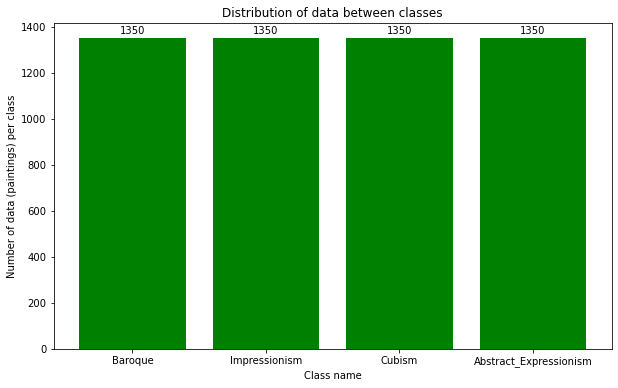

In [4]:
data = np.load('wikiart_hw2.npz')
X = data["X"]
Y = data["y"]
class_names = data["class_names"]

counts = {}
for i in range(4):
    counts[class_names[i]] = np.sum(Y == i)


print(f"Number of classes: {len(class_names)}\n")

for class_name in class_names:
    print(f"- {class_name}: {counts[class_name]}  samples")
print(f"\nTotal: {sum(counts.values())} samples")

plt.figure(figsize=(10,6))
plt.bar(counts.keys(), counts.values(), color='green')
plt.title("Distribution of data between classes")
plt.xlabel("Class name")
plt.ylabel("Number of data (paintings) per class")
plt.bar_label(plt.bar(counts.keys(), counts.values(), color='green'), padding=3)
plt.show()

### Device selection

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Creating tensors with data

In [6]:
# loading data into tensors

x_tensor = torch.tensor(X, dtype=torch.float32) / 255.0
x_tensor = x_tensor.permute(0, 3, 1, 2)

y_tensor = torch.tensor(Y, dtype=torch.int64)

print(f"x tensor: {x_tensor.shape}")
print(f"y tensor: {y_tensor.shape}")

x tensor: torch.Size([5400, 3, 32, 32])
y tensor: torch.Size([5400])


### Train-Val-Test split

Train split: x:torch.Size([3200, 3, 32, 32]) y:torch.Size([3200])
  - Baroque: 800
  - Impressionism: 800
  - Cubism: 800
  - Abstract_Expressionism: 800
Val split:   x:torch.Size([800, 3, 32, 32]) y:torch.Size([800])
  - Baroque: 200
  - Impressionism: 200
  - Cubism: 200
  - Abstract_Expressionism: 200
Test split:  x:torch.Size([1400, 3, 32, 32]) y:torch.Size([1400])
  - Baroque: 350
  - Impressionism: 350
  - Cubism: 350
  - Abstract_Expressionism: 350


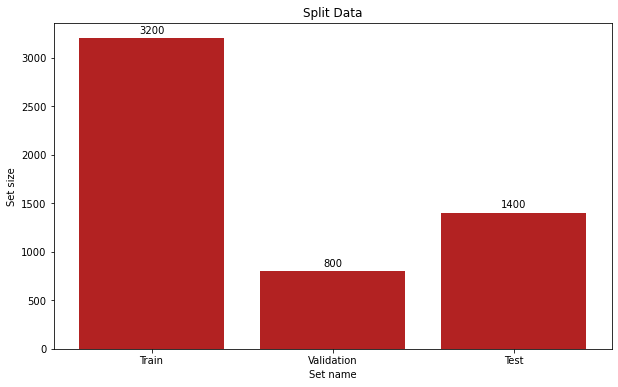

In [7]:
from sklearn.model_selection import train_test_split

# 1st split to create training data
x_train, x_temp, y_train, y_temp = train_test_split(x_tensor, y_tensor, test_size=0.407407407, random_state=SEED, stratify=y_tensor)

# 2nd split to create validation and test data
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.63636363, random_state=SEED, stratify=y_temp)

print(f"Train split: x:{x_train.shape} y:{y_train.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_train==i).sum().item()}")
print(f"Val split:   x:{x_val.shape} y:{y_val.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_val==i).sum().item()}")
print(f"Test split:  x:{x_test.shape} y:{y_test.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_test==i).sum().item()}")

plt.figure(figsize=(10, 6))
plt.bar(["Train", "Validation", "Test"], [x_train.shape[0], x_val.shape[0], x_test.shape[0]], color='firebrick')
plt.title("Split Data")
plt.xlabel("Set name")
plt.ylabel("Set size")
plt.bar_label(plt.bar(["Train", "Validation", "Test"], [x_train.shape[0], x_val.shape[0], x_test.shape[0]], color='firebrick'), padding=3)
plt.show()

### Datasets and dataloaders

In [8]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 16

# datasets(for dataloaders)
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)

# necessary for reproducibility
# (apparently if this generator isn't used in the training dataloader, reproducibility isn't guaranteed)
g = torch.Generator()
g.manual_seed(SEED)

# dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# debugging
print(f"Train batches: {len(train_dataloader)}")
print(f"Validation batches: {len(val_dataloader)}")
print(f"Test batches: {len(test_dataloader)}")

Train batches: 200
Validation batches: 50
Test batches: 88


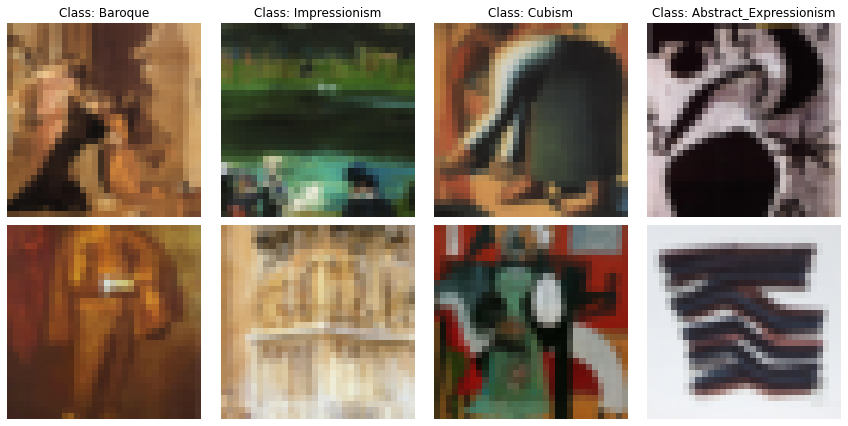

In [9]:
# a few samples

samples_per_class = {0: [], 1: [], 2: [], 3: []}

for i in range(len(y_tensor)):
    label = y_tensor[i].item()
    if len(samples_per_class[label]) < 2:
        samples_per_class[label].append(x_tensor[i])
    if all(len(images) == 2 for images in samples_per_class.values()):
        break

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for class_idx in range(4):
    for sample_idx in range(2):
        img_tensor = samples_per_class[class_idx][sample_idx]
        img_np = img_tensor.permute(1, 2, 0).numpy()
        if img_np.max() > 1.0:
            img_np = img_np / 255.0
        img_np = np.clip(img_np, 0, 1)
        ax = axes[sample_idx, class_idx]
        ax.imshow(img_np)
        if sample_idx == 0:
            ax.set_title(f"Class: {class_names[class_idx]}")
        ax.axis("off")

plt.tight_layout()
plt.show()

### Q0.1 Από την οπτικοποίηση, ποια οπτικά γνωρίσματα φαίνεται να διαφοροποιούν περισσότερο τα τέσσερα κινήματα μεταξύ τους (χρωματική παλέτα, υφή, σύνθεση, παρουσία θέματος); Ποια ζευγάρια κλάσεων αναμένετε να είναι πιο εύκολο να μπερδέψει ένας ταξινομητής, και γιατί; Αν ένας άνθρωπος έβλεπε τις ίδιες εικόνες resized σε 32×32, ποιο κίνημα θα ήταν πιο δύσκολο να ξεχωρίσει;
**A: Τα οπτικά γνωρίσματα που διαφοροποιούν περισσότερο τα τέσσερα κινήματα είναι η χρωματική παλέτα και η παρουσία (ή μη) σαφούς θέματος.**  
**- Το Μπαρόκ ξεχωρίζει από τον έντονο, δραματικό φωτισμό (φωτεινό θέμα με σκούρο φόντο), την ζωτικότητα των μορφών.**  
**- Ο Ιμπρεσιονισμός από τις πιο φωτεινές, παστέλ αποχρώσεις και τις υπαίθριες σκηνές.**  
**- O Κυβισμός εστιάζει σε συνθέσεις από γεωμετρικά σχήματα.**  
**- Αφαιρετικός Εξπρεσιονισμός χαρακτηρίζεται από την πλήρη απουσία αναγνωρίσιμου θέματος.**  
**Αναμένουμε ένας ταξινομητής να μπερδέψει πιο εύκολα τον Κυβισμό με τον Αφαιρετικό Εξπρεσιονισμό, καθώς αμφότερα στερούνται ρεαλιστικών αναπαραστάσεων. Αν ένας άνθρωπος έβλεπε τις εικόνες σε ανάλυση 32x32, το πιο δύσκολο κίνημα να ξεχωρίσει θα ήταν πιθανότατα ο Κυβισμός, διότι σε τόσο χαμηλή ανάλυση οι αιχμηρές γεωμετρικές ακμές και οι πολλαπλές οπτικές γωνίες πολτοποιούνται, κάνοντάς τον να μοιάζει με τυχαίες κηλίδες, μπερδεύοντάς τον με Αφαιρετικό Εξπρεσιονισμό.**

### Training-Evaluation functions

In [10]:
import torch.nn as nn
from sklearn.metrics import f1_score, confusion_matrix

class baseline_FNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.linear_relu_stack = nn.Sequential(
            nn.Linear(in_features=3*32*32, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=32),
            nn.ReLU(),
            nn.Linear(in_features=32, out_features=4)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # forward pass
        logits = model(images)
        # loss calculation
        loss = criterion(logits, labels)
        # backward pass
        loss.backward()
        # weights update
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            images = images.to(device)
            labels = labels.to(device)

            # forward pass
            logits = model(images)
            # losss calculation
            loss = criterion(logits, labels)

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples
    epoch_f1_macro = f1_score(all_labels, all_preds, average='macro')
    epoch_loss_cm = confusion_matrix(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1_macro, epoch_loss_cm


### Training

In [11]:
from torch.optim import Adam
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
cpu_time = -1
gpu_time = -1

model = baseline_FNN().to(device)
EPOCHS = 30
LEARNING_RATE = 0.001
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

best_f1_val = -1
best_model_path = "best_baseline_fnn.pth"

print("Starting training...\n")

start_time = time.time()

for epoch in range(EPOCHS):
    # train (adjusting weights)
    train_loss, train_acc = train_one_epoch(model, train_dataloader, optimizer, criterion)

    # evaluate
    val_loss, val_acc, val_f1, val_cm = evaluate(model, val_dataloader, criterion)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    if val_f1>best_f1_val:
        best_f1_val = val_f1
        torch.save(model.state_dict(), best_model_path)

    # current epoch results
    print(f"Epoch [{epoch+1}/{EPOCHS}]  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
    print("-" * 100)
end_time = time.time()

print(f"Training complete!")
if device==torch.device("cpu"):
    cpu_time = end_time - start_time
    print(f"Time: {cpu_time:.4f} seconds")
else:
    gpu_time = end_time - start_time
    print(f"Time: {gpu_time:.4f} seconds")

Using device: cpu
Starting training...

Epoch [1/30]  Train Loss: 1.3693 | Train Acc: 31.81%  Val Loss:   1.3358 | Val Acc:   37.38% | Val F1: 0.3151
----------------------------------------------------------------------------------------------------
Epoch [2/30]  Train Loss: 1.3262 | Train Acc: 37.03%  Val Loss:   1.3000 | Val Acc:   41.38% | Val F1: 0.3612
----------------------------------------------------------------------------------------------------
Epoch [3/30]  Train Loss: 1.2769 | Train Acc: 39.78%  Val Loss:   1.2709 | Val Acc:   43.38% | Val F1: 0.4063
----------------------------------------------------------------------------------------------------
Epoch [4/30]  Train Loss: 1.2481 | Train Acc: 42.38%  Val Loss:   1.3782 | Val Acc:   38.00% | Val F1: 0.3322
----------------------------------------------------------------------------------------------------
Epoch [5/30]  Train Loss: 1.2386 | Train Acc: 42.81%  Val Loss:   1.2676 | Val Acc:   41.88% | Val F1: 0.3727
------

### Training on CPU

In [12]:
device = torch.device("cpu")

if cpu_time == -1:
    print(">>> Started training using CPU...")

    model_cpu = baseline_FNN().to(device)
    optimizer_cpu = Adam(model_cpu.parameters(), lr=LEARNING_RATE)

    start_time = time.time()
    for epoch in range(EPOCHS):
        train_one_epoch(model_cpu, train_dataloader, optimizer_cpu, criterion)
    end_time = time.time()
    cpu_time = end_time - start_time
    print(f">>> CPU training complete! Time: {cpu_time:.2f} seconds")

# comparison
if gpu_time!=-1 and cpu_time!=-1:
    speedup = cpu_time / gpu_time
    quicker = "GPU" if speedup>1 else "CPU"
    slower = "CPU" if speedup>1 else "GPU"
    print(quicker + f" was {speedup:.4f} times quicker than the " + slower)
else:
    print("No GPU (CUDA) is available for training.")

# for safety
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

No GPU (CUDA) is available for training.


### Best model evaluation on test set

In [13]:
best_model = baseline_FNN().to(device)
best_model.load_state_dict(torch.load("best_baseline_fnn.pth"))

test_loss, test_acc, test_f1, test_cm = evaluate(best_model, test_dataloader, criterion)

print("=======  Baseline FNN model evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(f"Test F1-macro: {test_f1}")
print(f"Test Confusion matrix:")
for row in test_cm:
    print(row)

=======  Baseline FNN model evaluation on TEST SET  =======
Test Loss: 1.2935160636901855
Test Accuracy: 0.48928571428571427
Test F1-macro: 0.48831031208019715
Test Confusion matrix:
[157  37  55 101]
[ 24 186  60  80]
[ 29  60 117 144]
[ 18  54  53 225]


### Learning curves (Loss and F1-macro)

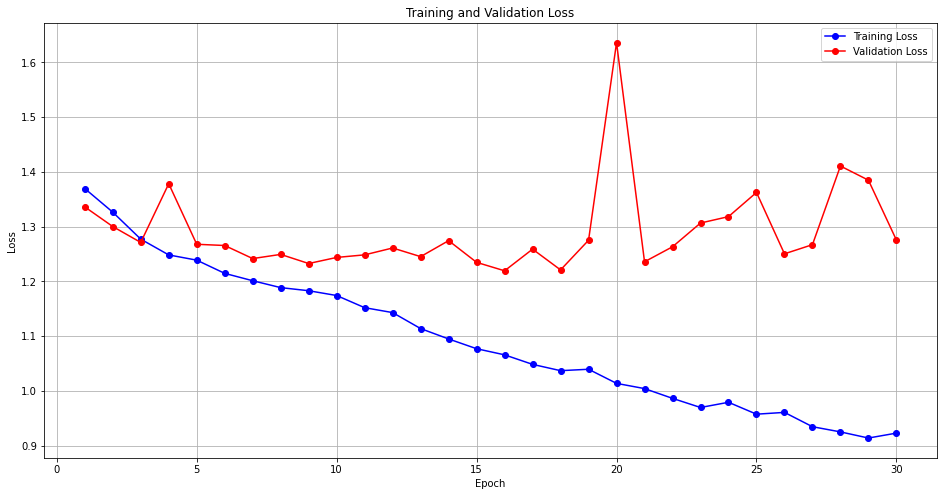

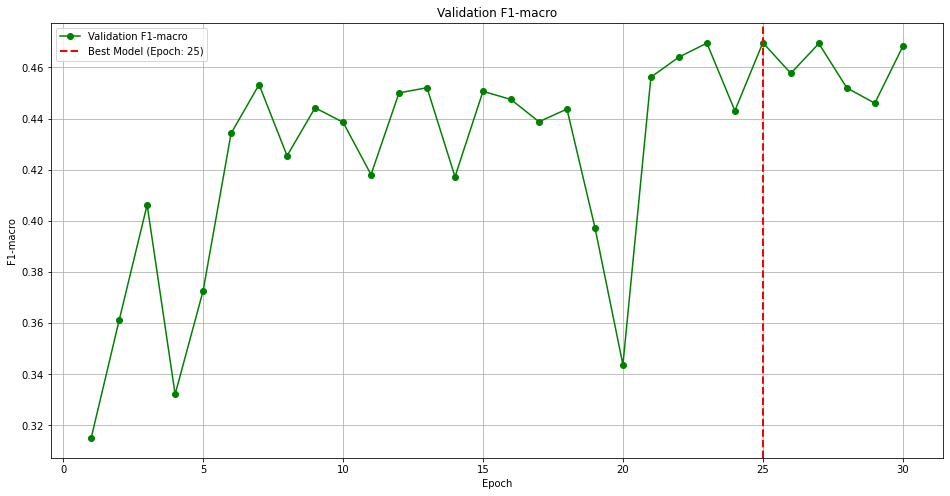

In [14]:
# loss
plt.figure(figsize=(16, 8))
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], 'bo-', label='Training Loss')
plt.plot(range(1, len(history['val_loss'])+1), history['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# f1-macro
plt.figure(figsize=(16, 8))
plt.plot(range(1, len(history['val_f1'])+1), history['val_f1'], 'go-', label='Validation F1-macro')
best_epoch = history['val_f1'].index(max(history['val_f1'])) + 1
plt.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Model (Epoch: {best_epoch})')
plt.title('Validation F1-macro')
plt.xlabel('Epoch')
plt.ylabel('F1-macro')
plt.legend()
plt.grid(True)

### Q1.1 Με βάση τα loss curves και την καμπύλη validation F1, παρατηρείτε overfitting, underfitting, ή ισορροπία; Σε ποια εποχή επιλέχθηκε το best model με κριτήριο το validation F1, και σε ποια θα είχε επιλεγεί αν χρησιμοποιούσατε το train loss ως κριτήριο; Γιατί η επιλογή με βάση το validation set είναι κρίσιμη; Ήταν αναμενόμενο το GPU speedup σε σχέση με την εκπαίδευση σε CPU για ένα δίκτυο αυτού του μεγέθους;

**A: Παρατηρώντας τις loss καμπύλες, βλέπουμε ότι ενώ το Training Loss μειώνεται συνεχώς καθώς περνούν οι εποχές, το Validation Loss σταματά να πέφτει και αρχίζει να σταθεροποιείται ή να αυξάνεται ελαφρώς μετά από κάποιο σημείο, με εμφανώς μεγαλύτερες διακυμάνσεις ωστόσο. Αυτό είναι σαφής ένδειξη overfitting, γεγονός που καθιστά κρίσιμη την επιλογή του καλύτερου μοντέλου με βάση το μέγιστο Validation F1-macro. Με αυτόν τον τρόπο κρατάμε την έκδοση του δικτύου στο σημείο που γενικεύει καλύτερα στα άγνωστα δεδομένα, προτού αρχίσει να αποστηθίζει το training set.**  

**Με βάση το κριτήριο του μέγιστου Validation F1-macro, το βέλτιστο μοντέλο επιλέχθηκε στην εποχή 25. Αντίθετα, αν χρησιμοποιούσαμε το Training Loss ως κριτήριο επιλογής, το μοντέλο θα είχε επιλεγεί στην Εποχή 29 ή 30 (τις τελευταίες), καθώς εκεί το σφάλμα εκπαίδευσης φτάνει στο απόλυτο ελάχιστο λόγω της αποστήθισης των δεδομένων. Το γεγονός αυτό καθιστά κρίσιμη την επιλογή με βάση το validation set (και μάλιστα validation f1), διότι μας επιτρέπει να "σώσουμε" την έκδοση του δικτύου στο σημείο που γενικεύει καλύτερα στα άγνωστα δεδομένα, ακριβώς πριν αρχίσει να προσαρμόζεται υπερβολικά στον θόρυβο του training set.**

**Όσον αφορά τους χρόνους, το GPU speedup περίπου 200%-300% (ανάλογα με τα resources που τυχαίνουν στο colab ήταν περίπου 2 με 3 φορές ταχύτερη η Τ4 GPU). Κάτι τέτοιο ήταν απολύτως αναμενόμενο για ένα δίκτυο αυτού του μεγέθους. Το Baseline FNN είναι ένα αρκετά "ρηχό" δίκτυο με απλούς πολλαπλασιασμούς πινάκων και η εκπαίδευση έχει μικρό πλήθος δεδομένων. Συνεπώς η χρήση GPU προσφέρει μεν μια σαφή και ικανοποιητική μείωση του χρόνου, αλλά δεν βλέπουμε την τεράστια επιτάχυνση (π.χ. >10x-15x) που θα προέκυπτε σε βαθιά Νευρωνικά Δίκτυα.**

### Q1.2 Παρουσιάστε accuracy, F1 macro, και confusion matrix του best model στο test set. Ποια κινήματα μπερδεύονται περισσότερο μεταξύ τους; Αναδιαμορφώστε (reshape) τα βάρη του πρώτου γραμμικού επιπέδου από σχήμα [128, 3072] σε [128, 3, 32, 32], κανονικοποιήστε κάθε «φίλτρο» στο [0, 1] (min-max ανά φίλτρο), και οπτικοποιήστε 16 από αυτά ως RGB εικόνες σε διάταξη 4×4. Συζητήστε γιατί το flat-pixel FFN δυσκολεύεται παρά την παρουσία της ReLU: τι «βλέπει» κάθε νευρώνας του πρώτου επιπέδου, και ποιο είδος δομής της εικόνας δεν μπορεί να εκμεταλλευτεί αυτή η αρχιτεκτονική;

**A: Με βάση την αξιολόγηση του βέλτιστου Baseline FNN μοντέλου στο Test Set, προέκυψαν τα εξής αποτελέσματα:**  
**Test Accuracy: 0.4892,  Test F1-macro: 0.4883 και confusion matrix:**  
|  | Pred_Baroque | Pred_Impressionism | Pred_Cubism | Pred_Abstract Expressionism |
| --- | --- | --- | --- | --- |
| True_Baroque | 157 | 37 | 55 | 101 |
| True_Impressionism | 24 | 186 | 60 | 80 |
| True_Cubism | 29 | 60 | 117 | 144 |
| True_Abstract Expressionism | 18 | 54 | 53 | 225 |

=======  Baseline FNN model evaluation on TEST SET  =======
Test Accuracy: 0.48928571428571427
Test F1-macro: 0.48831031208019715




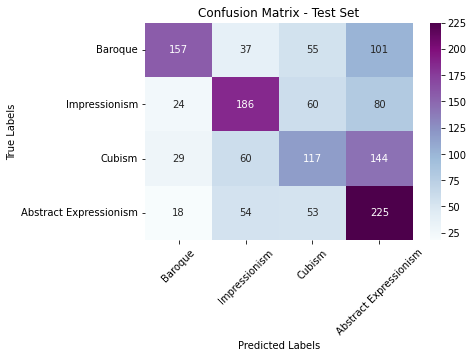

In [15]:
import seaborn as sns

print("=======  Baseline FNN model evaluation on TEST SET  =======")
print(f"Test Accuracy: {test_acc}")
print(f"Test F1-macro: {test_f1}\n\n")

class_names = ['Baroque', 'Impressionism', 'Cubism', 'Abstract Expressionism']

plt.figure(figsize=(6, 4))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

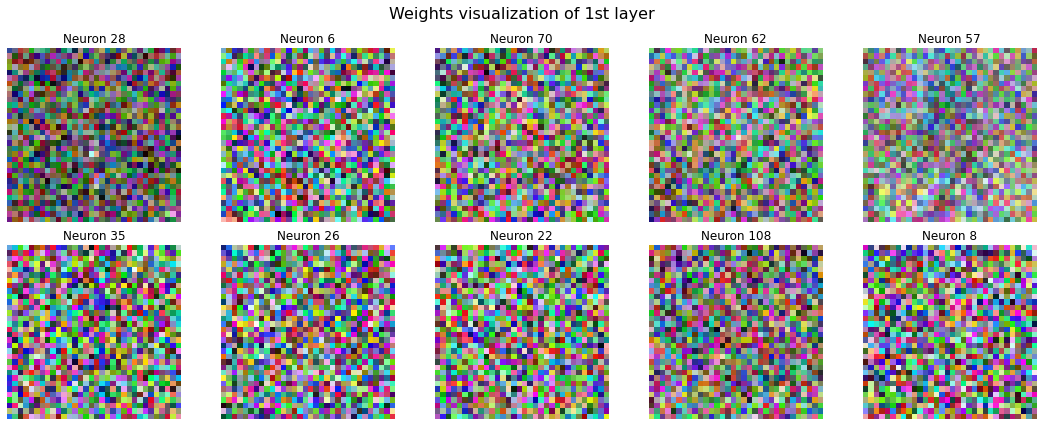

In [16]:
weights = best_model.linear_relu_stack[0].weight.data.cpu()

weights_reshaped = weights.view(128, 3, 32, 32) # "un-flatten"
random_neurons = random.sample(range(128), 10)  # choose 10 random neurons

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, neuron_idx in enumerate(random_neurons):
    w = weights_reshaped[neuron_idx]

    # min-max scaling to [0,1]
    w_min = w.min()
    w_max = w.max()
    w_norm = (w - w_min) / (w_max - w_min)

    w_img = w_norm.permute(1, 2, 0).numpy()

    axes[i].imshow(w_img)
    axes[i].axis('off')
    axes[i].set_title(f'Neuron {neuron_idx}')

plt.suptitle("Weights visualization of 1st layer", fontsize=16)
plt.tight_layout()
plt.show()